In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
final_cleaned_df=pd.read_csv(r"D:\Data Analyst\EXCEL\supplychain\cleaned\final_cleaned.csv")

In [70]:
eda_data=final_cleaned_df.copy()

# Structure of the Notebook

1. Introduction
2. Dataset Overview
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Time Series Analysis
7. Supply Chain Analysis
8. Customer Analysis
9. Product Analysis
10. Inventory Analysis
11. Shipping Analysis
12. Profitability Analysis
13. Summary of Insights

### Remove unwanted columns for EDA

In [71]:
eda_data.columns

Index(['Unnamed: 0', 'order_line_id', 'order_id', 'date_id', 'order_date',
       'customer_id', 'product_id', 'category', 'seller_id', 'seller_rating',
       'location_id_x', 'delivery_person_id', 'payment_id', 'campaign_id',
       'fulfillment_id', 'quantity', 'unit_price', 'discount_percentage',
       'tax_percentage', 'shipping_fee', 'expected_delivery_date',
       'actual_delivery_date', 'delivery_rating', 'order_status',
       'return_flag', 'refund_amount', 'return_date', 'customer_rating',
       'review_text', 'sentiment_score', 'delivery_delay_days',
       'delivery_sla_days', 'gross_amount', 'discount_amount', 'tax_amount',
       'net_amount', 'product_name', 'brand', 'first_name', 'email_x',
       'phone_number_x', 'marital_status', 'payment_method',
       'payment_provider', 'description', 'seller_name', 'email_y',
       'phone_number_y', 'join_date', 'location_id_y', 'rating',
       'category_focus', 'bank_name', 'bank_account_number', 'ifsc_code',
       'deli

In [72]:
df2=eda_data[['order_line_id','order_date','customer_id', 'product_id', 'category','seller_id', 'seller_rating','location_id_x','delivery_person_id','payment_id', 'campaign_id','fulfillment_id','quantity', 'unit_price', 'discount_percentage', 'tax_percentage', 'shipping_fee', 'expected_delivery_date', 'actual_delivery_date', 'delivery_rating', 'order_status', 'return_flag', 'refund_amount', 'return_date', 'customer_rating', 'review_text', 'sentiment_score', 'delivery_delay_days', 'delivery_sla_days', 'gross_amount', 'discount_amount', 'tax_amount', 'net_amount', 'product_name', 'brand', 'first_name', 'marital_status', 'payment_method', 'payment_provider', 'seller_name', 'delivery_person_name', 'employment_type', 'vehicle_type', 'state', 'city', 'postal_code', 'region']]


### Data inspection


- Shape	Number of rows and columns
- Columns	Available fields
- Head	Sample records
- Info	Data types and null values
- Describe	Numeric summary
- Duplicates	Duplicate records
- Missing Values	Null counts
- Unique Values	Category counts

In [73]:
df2.shape

(790732, 47)

In [74]:
df2.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id_x,delivery_person_id,payment_id,...,payment_method,payment_provider,seller_name,delivery_person_name,employment_type,vehicle_type,state,city,postal_code,region
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,Debit Card,Mastercard,"Virk, Kamdar and Kakar",Bhamini Acharya,Full-Time,Van,Karnataka,Bengaluru,843810,South
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,Debit Card,Visa,"Chauhan, Bahl and Sem",Emir Roy,Contract,Bike,Madhya Pradesh,Bhopal,406047,Central
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,UPI,Paytm,Loke-Gupta,Akarsh Bala,Full-Time,EV Bike,Delhi,Dwarka,246344,North
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,Debit Card,Visa,Sengupta-D’Alia,Urvi Sabharwal,Contract,Scooter,West Bengal,Kharagpur,705775,East
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,Wallet,Amazon Pay,Varghese Group,Vivaan Warrior,Full-Time,EV Bike,Haryana,Faridabad,744789,North


In [75]:
df2.describe()

,seller_rating,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,refund_amount,customer_rating,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount,postal_code
count,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.0,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.000000,7.907320e+05,790732.000000
mean,3.933004,3.001877,1.443109e+04,4.998254,5.0,116.332926,3.999889,-15.148007,3.717985,0.379188,0.450298,2.663600,4.322148e+04,2156.610857,2161.074214,4.334228e+04,525987.900046
std,0.888860,1.413882,5.030919e+04,2.886348,0.0,72.308419,0.835484,47.047367,0.887309,0.455638,0.668581,1.698761,1.670267e+05,9589.267398,8351.335561,1.672835e+05,259082.111332
min,1.000000,1.000000,2.000000e+01,0.000000,5.0,46.270000,1.000000,-215.790000,1.000000,-1.000000,0.000000,1.000000,2.000000e+01,0.000000,1.000000,6.536000e+01,113106.000000
25%,3.700000,2.000000,6.990000e+02,2.500000,5.0,46.270000,3.700000,0.000000,3.300000,0.180000,0.000000,1.000000,1.598000e+03,56.780100,79.900000,1.743270e+03,273826.000000
50%,4.100000,3.000000,1.999000e+03,4.990000,5.0,86.640000,4.200000,0.000000,3.800000,0.450000,0.000000,2.000000,5.397000e+03,220.310400,269.850000,5.480865e+03,522344.000000
75%,4.500000,4.000000,8.499000e+03,7.500000,5.0,215.790000,4.600000,0.000000,4.400000,0.730000,1.000000,5.000000,2.249500e+04,974.610000,1124.750000,2.240403e+04,755367.000000
max,5.000000,5.000000,1.150000e+06,10.000000,5.0,215.790000,5.000000,0.000000,5.000000,1.000000,2.000000,5.000000,5.750000e+06,572700.000000,287500.000000,6.031796e+06,989497.000000


In [76]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 47 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_line_id           790732 non-null  object 
 1   order_date              790732 non-null  object 
 2   customer_id             790732 non-null  object 
 3   product_id              790732 non-null  object 
 4   category                790732 non-null  object 
 5   seller_id               790732 non-null  object 
 6   seller_rating           790732 non-null  float64
 7   location_id_x           790732 non-null  object 
 8   delivery_person_id      790732 non-null  object 
 9   payment_id              790732 non-null  object 
 10  campaign_id             790732 non-null  object 
 11  fulfillment_id          790732 non-null  object 
 12  quantity                790732 non-null  int64  
 13  unit_price              790732 non-null  int64  
 14  discount_percentage 

In [77]:
df2.columns

Index(['order_line_id', 'order_date', 'customer_id', 'product_id', 'category',
       'seller_id', 'seller_rating', 'location_id_x', 'delivery_person_id',
       'payment_id', 'campaign_id', 'fulfillment_id', 'quantity', 'unit_price',
       'discount_percentage', 'tax_percentage', 'shipping_fee',
       'expected_delivery_date', 'actual_delivery_date', 'delivery_rating',
       'order_status', 'return_flag', 'refund_amount', 'return_date',
       'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'delivery_sla_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount', 'product_name', 'brand',
       'first_name', 'marital_status', 'payment_method', 'payment_provider',
       'seller_name', 'delivery_person_name', 'employment_type',
       'vehicle_type', 'state', 'city', 'postal_code', 'region'],
      dtype='object')

In [78]:
df2.loc[:, 'order_date'] = pd.to_datetime(df2['order_date'])

# Business Question

### What are the total orders placed

In [79]:

Total_orders=df2['order_line_id'].drop_duplicates().count()
Total_orders

np.int64(790732)

### How many customers placed orders

In [80]:
# Customers
Customers=df2['customer_id'].drop_duplicates().count()
Customers

np.int64(90818)

### How many sellers are there

In [81]:
# Sellers
Sellers=df2['seller_id'].drop_duplicates().count()
Sellers

np.int64(4563)

### What are the orders placed ever_day

In [82]:
#Transactions per date
Transactions = (
    df2.groupby('order_date')['payment_id']
       .count()
       .reset_index(name='transactions')
       .sort_values('order_date', ascending=False)
)

Transactions

,order_date,transactions
365,2026-04-02,2195
364,2026-04-01,2150
363,2026-03-31,2200
362,2026-03-30,2216
361,2026-03-29,2135
...,...,...
4,2025-04-06,2173
3,2025-04-05,2156
2,2025-04-04,2158
1,2025-04-03,2098


# Sales Analysis

### How much revenue did the company generate?

In [83]:
Revenue=round(sum(df2['net_amount']),2)
Revenue

34272128208.32

### Monthly Revenue Trend

In [91]:
df2['order_date'].dtype
df2.loc[:,'order_date']=pd.to_datetime(df2['order_date'])

In [92]:
Monthly_revenue = (
    df2.groupby(df2['order_date'].dt.to_period('M'))['net_amount']
       .sum()
       .reset_index(name='monthly_revenue')
)
Monthly_revenue

,order_date,monthly_revenue
0,2025-04,2.842805e+09
1,2025-05,2.878418e+09
2,2025-06,2.797245e+09
3,2025-07,2.892562e+09
4,2025-08,2.887323e+09
5,2025-09,2.735873e+09
6,2025-10,2.804357e+09
7,2025-11,2.840193e+09
8,2025-12,2.871660e+09
9,2026-01,2.919455e+09


In [93]:
Monthly_revenue['order_date'] = Monthly_revenue['order_date'].dt.to_timestamp()

### Removed incomplete months

In [ ]:
#Remove incomplete months

Monthly_revenue = Monthly_revenue[
    Monthly_revenue['order_date'] < pd.Timestamp('2026-04-01')
]

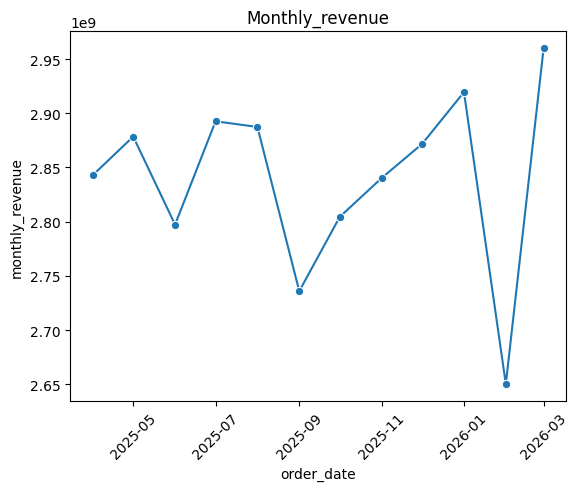

In [99]:
plt.title("Monthly_revenue")
sns.lineplot(data=Monthly_revenue, x='order_date', y='monthly_revenue', marker='o')
plt.xticks(rotation=45)
plt.show()

### Top 10 Revenue Generating Products

In [ ]:
top_10_products = (
    df2.groupby(['product_id', 'product_name'])['net_amount']
       .sum()
       .reset_index()
       .sort_values('net_amount', ascending=False)
       .head(10)
)

top_10_products[['product_name','net_amount']]

,product_name,net_amount
970,Submariner Date Automatic,2.121628e+09
971,Speedmaster Moonwatch Professional,1.093409e+09
1249,Sony VPL-FHZ60 6000L Laser,8.971965e+08
22,Z8 Mirrorless,6.495340e+08
1115,Nord Stage 3 88 Key,6.207335e+08
16,MSI Raider GE78 HX,4.837243e+08
1240,PowerLite L400U Laser WUXGA,4.811351e+08
20,EOS R6 Mark II,4.765599e+08
1101,Les Paul Standard 60s,4.713287e+08
1247,LG CineBeam HU710PW 4K UST,4.542683e+08


In [108]:
top_10_products

,product_id,product_name,net_amount
970,PROD000971,Submariner Date Automatic,2.121628e+09
971,PROD000972,Speedmaster Moonwatch Professional,1.093409e+09
1249,PROD001250,Sony VPL-FHZ60 6000L Laser,8.971965e+08
22,PROD000023,Z8 Mirrorless,6.495340e+08
1115,PROD001116,Nord Stage 3 88 Key,6.207335e+08
16,PROD000017,MSI Raider GE78 HX,4.837243e+08
1240,PROD001241,PowerLite L400U Laser WUXGA,4.811351e+08
20,PROD000021,EOS R6 Mark II,4.765599e+08
1101,PROD001102,Les Paul Standard 60s,4.713287e+08
1247,PROD001248,LG CineBeam HU710PW 4K UST,4.542683e+08


In [118]:
top = (
    df2[['product_id', 'product_name', 'unit_price']]
    .sort_values('unit_price', ascending=False)
    .drop_duplicates(subset='product_id')
    .head(10)
)

top

,product_id,product_name,unit_price
156012,PROD000971,Submariner Date Automatic,1150000
415738,PROD000972,Speedmaster Moonwatch Professional,580000
624501,PROD001250,Sony VPL-FHZ60 6000L Laser,499999
790725,PROD001116,Nord Stage 3 88 Key,349999
477853,PROD000023,Z8 Mirrorless,349990
63204,PROD001248,LG CineBeam HU710PW 4K UST,249999
78939,PROD001102,Les Paul Standard 60s,249999
555141,PROD001241,PowerLite L400U Laser WUXGA,249999
156119,PROD000017,MSI Raider GE78 HX,249990
35,PROD000021,EOS R6 Mark II,239990


### Top Categories by Revenue

In [119]:
top_categories=(
    df2.groupby(['category'])['net_amount']
       .sum()
       .reset_index()
       .sort_values('net_amount', ascending=False)
       .head(10)
)

top_categories

,category,net_amount
6,Electronics,1.222135e+10
13,Music & Instruments,5.447600e+09
12,Jewellery,5.276126e+09
14,Office Supplies,3.746905e+09
8,Gaming,1.445363e+09
11,Home,1.150213e+09
7,Footwear,7.801014e+08
2,Bags & Luggage,7.534758e+08
16,Sports,6.198205e+08
0,Automotive,5.527822e+08
